# IndicCorpV2 Dataset Exploration Notebook

Interactive exploration of the IndicCorpV2 dataset - the largest collection of Indic language texts.

**Dataset Stats:**
- 24 languages (23 Indic + Indian English)
- 20.9 Billion tokens
- Web-crawled from Indian websites
- License: CC-0

IndicCorpV2 is web-crawled data without inherent quality tiers or folder-based difficulty signals. It's essentially a mixed bag that spans B0-B3, but you can't easily separate them without using filtering techniques because:

1. No folder structure by difficulty
2. No metadata indicating content type
3. Mix of high-quality (news, wiki) and low-quality (social, spam) content

Alternatives:
You already have cleaner Indic sources:

1. Sangraha Verified (structured, likely pre-filtered)
2. FineWeb2 Indic subset (likely higher quality)


Plan of usage:

1B Model
1. B0 -If possible avoid it, use Sangraha Verified + Fine Web Edu Indic . use <5% (only extremely simple text) if needed because Grammar stability needs clean data)

3B Model
1. B1 - Use 30-40% of Indic mix, use "news" + "blog" (will need creation of tags)

8B Model
1. B1 +B2 - Use 30% of Indic mix, add data for  "formal" + "wiki"

70B Model
1. Load entire data

In [1]:
!pip install datasets pandas numpy tqdm matplotlib seaborn -q

In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import re

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Language and Script Mapping

In [3]:
# Available languages in IndicCorpV2
LANGUAGES = {
    'as': 'Assamese', 'bd': 'Bodo', 'bn': 'Bengali', 'dg': 'Dogri',
    'en': 'English', 'gom': 'Konkani', 'gu': 'Gujarati', 'hi': 'Hindi',
    'kha': 'Khasi', 'kn': 'Kannada', 'ks': 'Kashmiri', 'mai': 'Maithili',
    'ml': 'Malayalam', 'mni': 'Manipuri', 'mr': 'Marathi', 'ne': 'Nepali',
    'or': 'Odia', 'pa': 'Punjabi', 'sa': 'Sanskrit', 'sat': 'Santali',
    'sd': 'Sindhi', 'ta': 'Tamil', 'te': 'Telugu', 'ur': 'Urdu'
}

SCRIPTS = {
    'as': 'Beng', 'bd': 'Deva', 'bn': 'Beng', 'dg': 'Deva',
    'en': 'Latn', 'gom': 'Deva', 'gu': 'Gujr', 'hi': 'Deva',
    'kha': 'Latn', 'kn': 'Knda', 'ks': 'Arab', 'mai': 'Deva',
    'ml': 'Mlym', 'mni': 'Beng', 'mr': 'Deva', 'ne': 'Deva',
    'or': 'Orya', 'pa': 'Guru', 'sa': 'Deva', 'sat': 'Olck',
    'sd': 'Arab', 'ta': 'Taml', 'te': 'Telu', 'ur': 'Arab'
}

# Display available languages
df_langs = pd.DataFrame([
    {'Code': code, 'Language': name, 'Script': SCRIPTS[code]}
    for code, name in LANGUAGES.items()
]).sort_values('Language')

print(f"Total Languages: {len(LANGUAGES)}")
display(df_langs)

Total Languages: 24


,Code,Language,Script
0,as,Assamese,Beng
2,bn,Bengali,Beng
1,bd,Bodo,Deva
3,dg,Dogri,Deva
4,en,English,Latn
6,gu,Gujarati,Gujr
7,hi,Hindi,Deva
9,kn,Kannada,Knda
10,ks,Kashmiri,Arab
8,kha,Khasi,Latn


## 3. Load and Explore a Single Language

In [22]:
from datasets import get_dataset_split_names

splits = get_dataset_split_names("ai4bharat/IndicCorpV2", config_name="indiccorp_v2")
print("Available splits for 'indiccorp_v2' configuration:")
for s in splits:
    print(f"- {s}")

Available splits for 'indiccorp_v2' configuration:
- asm_Beng
- ben_Beng
- brx_Deva
- doi_Deva
- gom_Deva
- guj_Gujr
- hin_Deva
- kan_Knda
- kas_Arab
- mai_Deva
- mal_Mlym
- mar_Deva
- mni_Mtei
- npi_Deva
- ory_Orya
- pan_Guru
- san_Deva
- snd_Deva
- tam_Taml
- tel_Telu
- urd_Arab
- khasi
- santhali


In [9]:
# Choose a language to explore
LANG_CODE = 'hi'  # Change this to explore different languages
SAMPLE_SIZE = 100

print(f"Loading {LANGUAGES[LANG_CODE]} dataset...")

# Mapping from 2-letter LANG_CODE to 3-letter prefix used in dataset config names
# Based on the data_files keys shown in previous error tracebacks
THREE_LETTER_LANG_CODE_MAP = {
    'as': 'asm', 'bd': 'brx', 'bn': 'ben', 'dg': 'doi',
    'gom': 'gom', 'gu': 'guj', 'hi': 'hin', 'kn': 'kan',
    'ks': 'kas', 'mai': 'mai', 'ml': 'mal', 'mni': 'mni',
    'mr': 'mar', 'ne': 'npi', 'or': 'ory', 'pa': 'pan',
    'sa': 'san', 'sd': 'snd', 'ta': 'tam', 'te': 'tel', 'ur': 'urd',
    'kha': 'khasi', # Special case for Khasi
    'sat': 'santhali' # Special case for Santali
}

# Construct the intended dataset configuration name, which will be used as the split name
# Fallback for languages not in the map (e.g., English, though not directly shown in data_files)
config_lang_prefix = THREE_LETTER_LANG_CODE_MAP.get(LANG_CODE, LANG_CODE)

if LANG_CODE in ['kha', 'sat']:
    # For Khasi and Santali, the split name is just the language name
    language_split_name = config_lang_prefix
elif LANG_CODE == 'en':
    # For English, it's typically en_Latn if it follows the pattern, but not explicitly in provided data_files
    # Using a common assumption here, might need adjustment if it still fails.
    language_split_name = 'eng_Latn'
else:
    language_split_name = f"{config_lang_prefix}_{SCRIPTS[LANG_CODE]}"

# The dataset builder has a single 'indiccorp_v2' configuration,
# but the different languages are exposed as distinct 'splits' within that configuration.
dataset_config_name = 'indiccorp_v2'

print(f"Attempting to load config: {dataset_config_name} with split: {language_split_name}")

# Load dataset with streaming using the overall configuration name and the language-specific split
dataset = load_dataset(
    "ai4bharat/IndicCorpV2",
    dataset_config_name, # Use 'indiccorp_v2' as the main configuration
    split=language_split_name, # Use the language-script combination as the specific split to load
    streaming=True
)

print(f"✓ Dataset loaded for {LANGUAGES[LANG_CODE]}")

Loading Hindi dataset...
Attempting to load config: indiccorp_v2 with split: hin_Deva
✓ Dataset loaded for Hindi


## 4. Collect and Analyze Samples

In [10]:
# Collect samples
samples = []
text_stats = []

print(f"Collecting {SAMPLE_SIZE} samples...")
for i, example in enumerate(tqdm(dataset, total=SAMPLE_SIZE)):
    if i >= SAMPLE_SIZE:
        break

    text = example.get('text', '')
    words = text.split()

    samples.append(text)
    text_stats.append({
        'char_count': len(text),
        'word_count': len(words),
        'unique_words': len(set(words)),
        'lexical_diversity': len(set(words)) / len(words) if words else 0
    })

df_stats = pd.DataFrame(text_stats)
print(f"✓ Collected {len(samples)} samples")

  0%|          | 0/100 [00:00<?, ?it/s]

✓ Collected 100 samples


In [11]:
# Summary statistics
print(f"\n{'='*60}")
print(f"Statistics for {LANGUAGES[LANG_CODE]}")
print(f"{'='*60}\n")

summary = df_stats.describe()
display(summary)

print(f"\nKey Metrics:")
print(f"  Average words per document: {df_stats['word_count'].mean():.0f}")
print(f"  Average characters per document: {df_stats['char_count'].mean():.0f}")
print(f"  Average lexical diversity: {df_stats['lexical_diversity'].mean():.3f}")
print(f"  Total tokens (in sample): {df_stats['word_count'].sum():,}")


Statistics for Hindi



,char_count,word_count,unique_words,lexical_diversity
count,100.000000,100.000000,100.000000,100.000000
mean,117.440000,23.130000,18.210000,0.430673
std,184.048375,36.095176,25.640993,0.439784
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,9.000000,2.000000,2.000000,0.303030
75%,219.250000,44.250000,37.000000,0.862461
max,1193.000000,231.000000,140.000000,1.000000



Key Metrics:
  Average words per document: 23
  Average characters per document: 117
  Average lexical diversity: 0.431
  Total tokens (in sample): 2,313


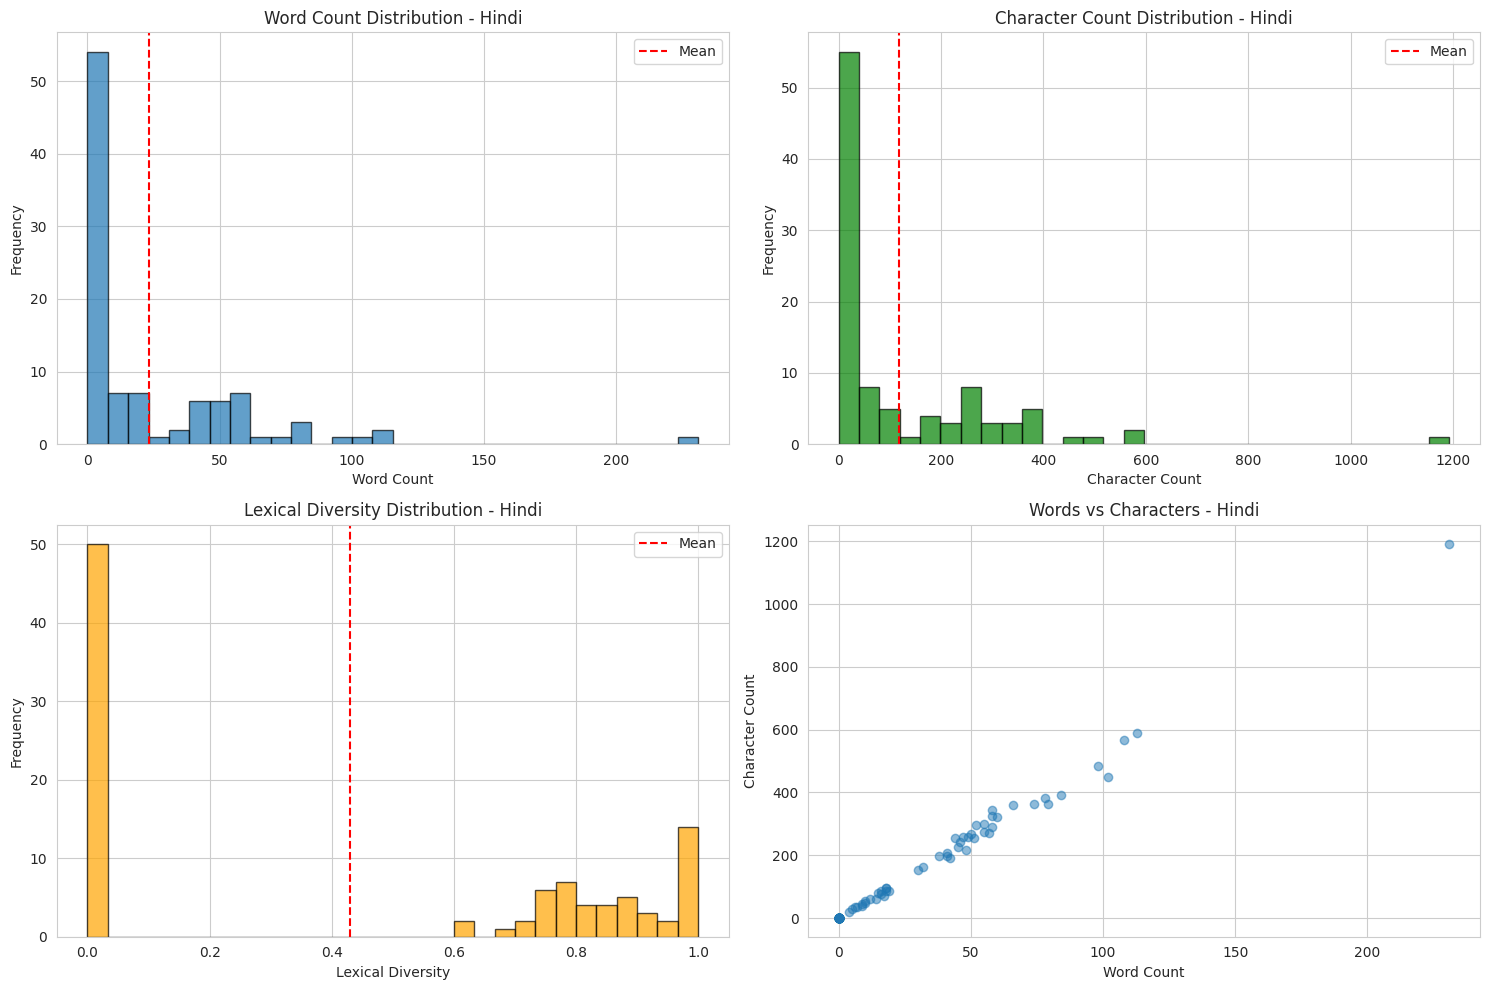

In [12]:
# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Word count distribution
axes[0, 0].hist(df_stats['word_count'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Word Count Distribution - {LANGUAGES[LANG_CODE]}')
axes[0, 0].axvline(df_stats['word_count'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].legend()

# Character count distribution
axes[0, 1].hist(df_stats['char_count'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Character Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Character Count Distribution - {LANGUAGES[LANG_CODE]}')
axes[0, 1].axvline(df_stats['char_count'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 1].legend()

# Lexical diversity
axes[1, 0].hist(df_stats['lexical_diversity'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_xlabel('Lexical Diversity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Lexical Diversity Distribution - {LANGUAGES[LANG_CODE]}')
axes[1, 0].axvline(df_stats['lexical_diversity'].mean(), color='red', linestyle='--', label='Mean')
axes[1, 0].legend()

# Word vs Character scatter
axes[1, 1].scatter(df_stats['word_count'], df_stats['char_count'], alpha=0.5)
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Character Count')
axes[1, 1].set_title(f'Words vs Characters - {LANGUAGES[LANG_CODE]}')

plt.tight_layout()
plt.show()

## 7. Sample Text Inspection

In [13]:
# Display sample texts
print(f"\nSample Texts from {LANGUAGES[LANG_CODE]}:")
print("="*80)

for i in range(min(5, len(samples))):
    print(f"\nSample {i+1}:")
    print(f"Length: {len(samples[i].split())} words")
    print("-" * 80)
    print(samples[i][:500])  # First 500 characters
    print("..." if len(samples[i]) > 500 else "")
    print("="*80)


Sample Texts from Hindi:

Sample 1:
Length: 9 words
--------------------------------------------------------------------------------
लोगों को बिलों संबंधी सुविधा देना ही उनका काम


Sample 2:
Length: 0 words
--------------------------------------------------------------------------------



Sample 3:
Length: 231 words
--------------------------------------------------------------------------------
इनेलो 1987 में उस वक्त ऐसे ही दोराहे पर खड़ी थी, जब पूर्व उपप्रधानमंत्री देवीलाल ने अपने पुत्र ओमप्रकाश चौटाला को अपना राजनीतिक उत्तराधिकारी घोषित किया था। हालांकि तब पार्टी पर देवीलाल की मजबूत पकड़ के चलते पार्टी टूटने से बच गई थी। 1989 में देवीलाल केन्द्र की राजनीति में सक्रिय हो गए थे और उनके उपप्रधानमंत्री बनने के पश्चात् उनके तीन बेटों जगदीश सिंह, रणजीत सिंह और ओमप्रकाश चौटाला में से रणजीत और ओमप्रकाश के बीच हरियाणा में उनकी राजनीतिक विरासत को लेकर जंग शुरू हो गई थी। उन परिस्थितियों में देव
...

Sample 4:
Length: 0 words
-------------------------------------------------------------------

## 8. Content Category Detection (Heuristic)


Content Category Distribution:
  conversational :  100 (100.0%)


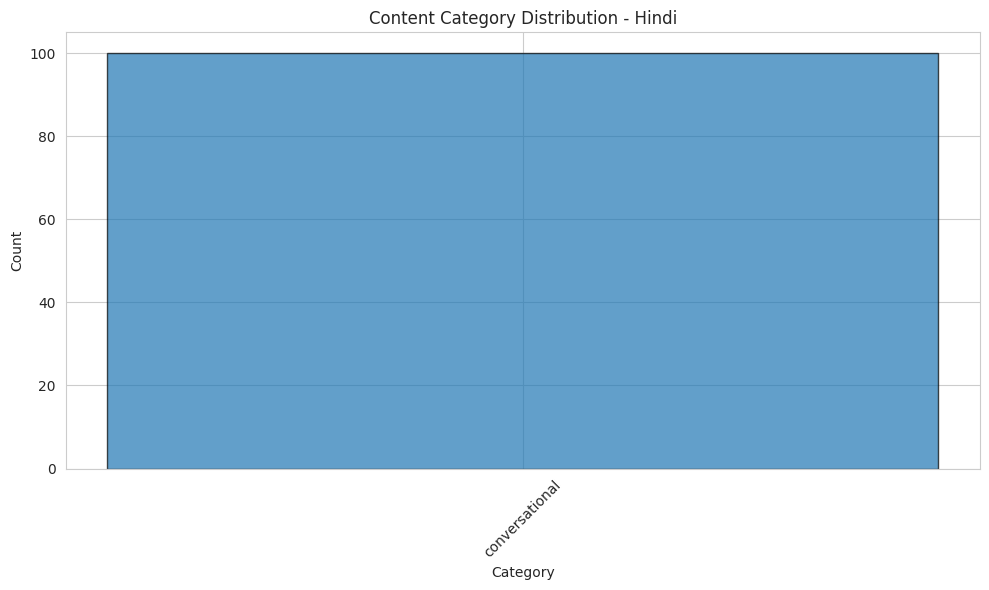

In [14]:
def detect_category(text):
    """Simple heuristic category detection"""
    text_lower = text.lower()

    # Count patterns
    has_date = bool(re.search(r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}', text))
    has_reference = bool(re.search(r'\[\d+\]', text))
    has_hashtag = bool(re.search(r'#\w+', text))

    words = text.split()
    avg_word_len = sum(len(w) for w in words) / len(words) if words else 0

    # Simple categorization
    if has_reference:
        return 'wiki'
    elif has_hashtag:
        return 'social'
    elif has_date and avg_word_len > 5:
        return 'news'
    elif avg_word_len > 6:
        return 'formal'
    else:
        return 'conversational'

# Categorize samples
categories = [detect_category(text) for text in samples]
category_counts = Counter(categories)

print("\nContent Category Distribution:")
print("="*60)
for cat, count in category_counts.most_common():
    pct = (count / len(samples)) * 100
    print(f"  {cat:15s}: {count:4d} ({pct:5.1f}%)")

# Visualize
plt.figure(figsize=(10, 6))
cats, counts = zip(*category_counts.most_common())
plt.bar(cats, counts, edgecolor='black', alpha=0.7)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title(f'Content Category Distribution - {LANGUAGES[LANG_CODE]}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Compare multiple languages
COMPARE_LANGS = ['hi', 'te', 'bn', 'ta', 'mr']  # Modify as needed
COMPARISON_SAMPLE_SIZE = 50

comparison_results = []

for lang in COMPARE_LANGS:
    print(f"\nAnalyzing {LANGUAGES[lang]}...")

    try:
        # Construct the split name based on the same logic as the single language loader
        config_lang_prefix = THREE_LETTER_LANG_CODE_MAP.get(lang, lang)
        if lang in ['kha', 'sat']:
            language_split_name = config_lang_prefix
        elif lang == 'en':
            language_split_name = 'eng_Latn'
        else:
            language_split_name = f"{config_lang_prefix}_{SCRIPTS[lang]}"

        ds = load_dataset(
            "ai4bharat/IndicCorpV2",
            "indiccorp_v2", # Use the overall configuration name
            split=language_split_name, # Use the language-script combination as the specific split
            streaming=True
        )

        stats = []
        for i, ex in enumerate(ds):
            if i >= COMPARISON_SAMPLE_SIZE:
                break
            words = ex['text'].split()
            stats.append({
                'word_count': len(words),
                'char_count': len(ex['text']),
                'lexical_diversity': len(set(words)) / len(words) if words else 0
            })

        df_lang = pd.DataFrame(stats)
        comparison_results.append({
            'Language': LANGUAGES[lang],
            'Code': lang,
            'Avg Words': df_lang['word_count'].mean(),
            'Avg Chars': df_lang['char_count'].mean(),
            'Avg Lexical Diversity': df_lang['lexical_diversity'].mean()
        })

    except Exception as e:
        print(f"  Error: {e}")

# Create comparison dataframe
df_comparison = pd.DataFrame(comparison_results)
print("\n" + "="*80)
print("LANGUAGE COMPARISON")
print("="*80)
display(df_comparison)


Analyzing Hindi...

Analyzing Telugu...

Analyzing Bengali...

Analyzing Tamil...

Analyzing Marathi...

LANGUAGE COMPARISON


,Language,Code,Avg Words,Avg Chars,Avg Lexical Diversity
0,Hindi,hi,25.14,126.98,0.426960
1,Telugu,te,19.78,156.20,0.463067
2,Bengali,bn,19.04,120.12,0.464237
3,Tamil,ta,10.74,103.02,0.480163
4,Marathi,mr,21.46,146.12,0.468488


Data Cleaning Efforts

1. Junk Removal

  1.1 Rule Based
  
    1. Length (10 < words < 10,000)
    2. Average word length (2-15 chars)
    3. Symbol ratio (< 30%)
    4. Line repetition (< 50%)
    5. Spam patterns (ads, hex dumps, etc.)
    6. Language detection (ensure it's actually the target language)

2. Language ID Filtering

    1. Ensure text is actually in the target language

3. Deduplication
4. Difficulty Classification
5. Content Category Classification (new,wiki,social,blog)